In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path # manage paths for the project
import re

In [3]:
# define the path of the data
data_path = Path('..') / 'data' / 'raw' / 'retail_etl_dataset.csv'

In [4]:
# indication of the type of the variable for issues with the IDE
df = pd.read_csv(data_path)
df

,invoice_id,customer_id,product,quantity,price,total_revenue,country,invoice_date
0,22951,1102.0,Mouse,2,525.96,1051.92,Colombia,2023-03-25
1,21238,1435.0,Printer,6,74.92,449.52,colombia,2023-11-23
2,29165,1348.0,Monitor,1,576.56,576.56,colombia,2023-05-13
3,24727,1270.0,Mouse,3,353.25,1059.75,Ecuador,14-09-2023
4,23965,1106.0,Mouse,7,312.70,2188.90,Chile,2023-05-28
...,...,...,...,...,...,...,...,...
5095,29205,1113.0,Laptop,4,92.47,369.88,colombia,2023-10-05
5096,29661,1099.0,Keyboard,9,353.80,3184.20,CO,2023-04-21
5097,20693,1493.0,Printer,3,628.16,1884.48,ecuador,2023-04-14
5098,29063,1396.0,Phone,6,981.74,5890.44,Peru,2023-02-03


In [5]:
# Initial exploration

print(f"Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("-" * 50)
df.info()

# problems detected
# > Null values
# > Type errorrs

Dimensions: 5100 rows, 8 columns
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   invoice_id     5100 non-null   int64  
 1   customer_id    4898 non-null   float64
 2   product        5100 non-null   str    
 3   quantity       5100 non-null   int64  
 4   price          5100 non-null   float64
 5   total_revenue  5100 non-null   float64
 6   country        5100 non-null   str    
 7   invoice_date   5087 non-null   str    
dtypes: float64(3), int64(2), str(3)
memory usage: 318.9 KB


In [6]:
# Null values analysis

nulls = df.isnull().sum()
nulls_percentage = (nulls / len(df)) * 100
df_null = pd.DataFrame({'Nulls': nulls, 'Percentage (%)': nulls_percentage})
print(df_null)

# Show only columns with null value
display(df_null[df_null['Nulls'] > 0].sort_values(by='Percentage (%)', ascending=False))

               Nulls  Percentage (%)
invoice_id         0        0.000000
customer_id      202        3.960784
product            0        0.000000
quantity           0        0.000000
price              0        0.000000
total_revenue      0        0.000000
country            0        0.000000
invoice_date      13        0.254902


,Nulls,Percentage (%)
customer_id,202,3.960784
invoice_date,13,0.254902


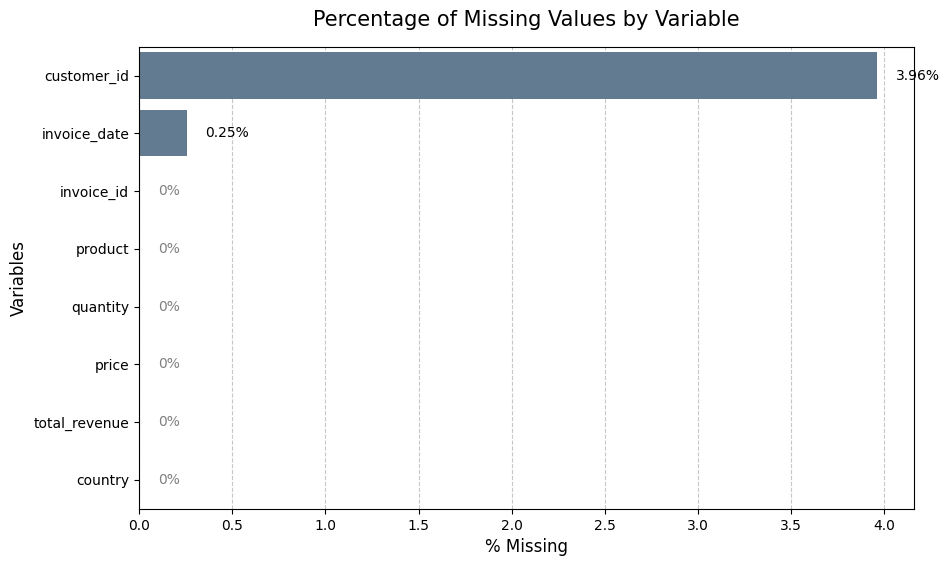

In [7]:
# We use the df_null dataframe created in the previous cell
# Sorting values so the variable with the most missing data appears at the top
df_miss = df_null.sort_values(by='Percentage (%)', ascending=False)

plt.figure(figsize=(10, 6))

# Plotting a horizontal bar chart (naniar style)
ax = sns.barplot(
    x='Percentage (%)', 
    y=df_miss.index, 
    data=df_miss, 
    color='#5b7c99' # A grayish-blue similar to naniar defaults
)

# Customizing labels and title
plt.title('Percentage of Missing Values by Variable', fontsize=15, pad=15)
plt.xlabel('% Missing', fontsize=12)
plt.ylabel('Variables', fontsize=12)

# Adding vertical grid lines for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Adding the exact percentage text at the end of each bar
for i, v in enumerate(df_miss['Percentage (%)']):
    if v > 0:
        ax.text(v + 0.1, i, f'{v:.2f}%', va='center', fontsize=10)
    else:
        ax.text(0.1, i, '0%', va='center', fontsize=10, color='gray')

In [8]:
# looking for duplicated rows

total_duplicated = df.duplicated().sum()
print(f"{total_duplicated} rows were found that were exactly the same")

if total_duplicated > 0:
    # sample of some duplicated rows
    display(df[df.duplicated(keep=False)].sort_values(by='invoice_id').head(4)) 

90 rows were found that were exactly the same


,invoice_id,customer_id,product,quantity,price,total_revenue,country,invoice_date
4048,20105,1380.0,Keyboard,6,275.47,1652.82,Colombia,2023-02-26
5090,20105,1380.0,Keyboard,6,275.47,1652.82,Colombia,2023-02-26
1339,20191,1224.0,Laptop,8,314.36,2514.88,ecuador,2023-06-08
5033,20191,1224.0,Laptop,8,314.36,2514.88,ecuador,2023-06-08


In [9]:
# show only duplicates by invoice_id 
dup_invoices = df.duplicated(subset=['invoice_id'], keep=False).sum()
print(f"rows with 'invoice_id' duplicated: {dup_invoices}")

rows with 'invoice_id' duplicated: 2131


In [10]:
# statics for numeric columns

display(df[['quantity', 'price', 'total_revenue']].describe())

# Problems detected:
# > negative values

,quantity,price,total_revenue
count,5100.000000,5100.000000,5100.000000
mean,4.776471,496.229952,2332.439496
std,2.825415,291.654276,2184.914094
min,-4.000000,-96.616618,-6719.280000
25%,3.000000,251.220000,692.310000
50%,5.000000,497.440000,1850.025000
75%,7.000000,742.112500,3611.070000
max,9.000000,999.510000,11294.130000


In [11]:
# unique values validation

df["country"].unique()

# We have the same category referenced in different ways

<StringArray>
['Colombia', 'colombia', 'Ecuador', 'Chile', 'ecuador', 'CO', 'Peru']
Length: 7, dtype: str

In [12]:
df["product"].unique # No problems here

<bound method Series.unique of 0          Mouse
1        Printer
2        Monitor
3          Mouse
4          Mouse
          ...   
5095      Laptop
5096    Keyboard
5097     Printer
5098       Phone
5099      Tablet
Name: product, Length: 5100, dtype: str>

In [13]:
# some business rules

# verifying total_revenue != quantity x price
expected_revenue = df['quantity'] * df['price']
revenue_diff = abs(df['total_revenue'] - expected_revenue)
bad_revenue_count = (revenue_diff > 0.01).sum()
print(f"rows with 'total_revenue' incorrect: {bad_revenue_count}")

rows with 'total_revenue' incorrect: 148


In [14]:
# negatives values
neg_quantities = (df['quantity'] < 1).sum()
neg_prices = (df['price'] <= 0).sum()
print(f"Negative quantities or zero: {neg_quantities}")
print(f"Negative prices or zero: {neg_prices}")

Negative quantities or zero: 149
Negative prices or zero: 101


In [15]:
# date formats
print("dates sample (invoice_date):")
print(df['invoice_date'].dropna().sample(10).values)

dates sample (invoice_date):
<StringArray>
['2023-12-26', '2023-12-02', '2023-06-20', '2023-01-07', '2023-04-02',
 '2023-02-20', '2023-06-22', '2023-08-06', '2023-11-23', '2023-05-26']
Length: 10, dtype: str


In [16]:
temp_dates = pd.to_datetime(df['invoice_date'], errors='coerce')
future_dates = (temp_dates > pd.to_datetime('2023-12-31')).sum()
print(f"Future dates rows (> 2023-12-31): {future_dates}")

Future dates rows (> 2023-12-31): 126


In [17]:
# Classify each invoice_date value into a format category
def classify_date_format(val):
    if pd.isna(val):
        return "null_like"
    s = str(val).strip()
    if re.match(r"^(N/A|NULL|nan|)$", s, re.IGNORECASE):
        return "null_like"
    if re.match(r"^\d{4}-\d{2}-\d{2}$", s):
        return "YYYY-MM-DD"
    if re.match(r"^\d{4}/\d{2}/\d{2}$", s):
        return "YYYY/MM/DD"
    if re.match(r"^\d{2}-\d{2}-\d{4}$", s):
        return "DD-MM-YYYY"
    return "other"

fmt_counts = df["invoice_date"].apply(classify_date_format).value_counts()
print("Distribution of invoice_date formats:")
print(fmt_counts)

# Null-like strings (N/A, NULL, empty) — distinct from pandas NaN nulls
null_like_count = (df["invoice_date"].apply(classify_date_format) == "null_like").sum()
print(f"\nNull-like date strings (N/A, NULL, empty): {null_like_count}")

Distribution of invoice_date formats:
invoice_date
YYYY-MM-DD    4909
YYYY/MM/DD      98
DD-MM-YYYY      78
null_like       13
other            2
Name: count, dtype: int64

Null-like date strings (N/A, NULL, empty): 13


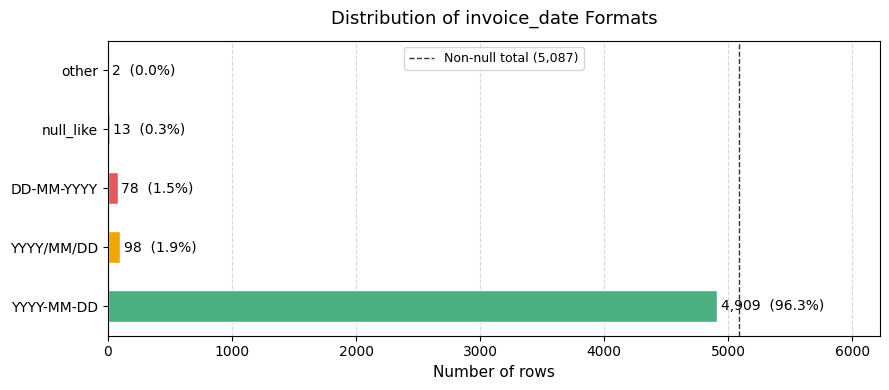

In [20]:
# Distribution of invoice_date formats — bar chart
COLORS = {
    "YYYY-MM-DD": "#4caf82",   # canonical — green
    "YYYY/MM/DD": "#f0a500",   # parseable but non-standard — amber
    "DD-MM-YYYY": "#e05c5c",   # wrong order — red
    "null_like":  "#aaaaaa",   # missing — grey
    "other":      "#9b59b6",   # unknown — purple
}

fig, ax = plt.subplots(figsize=(9, 4))

colors = [COLORS.get(fmt, "#cccccc") for fmt in fmt_counts.index]
bars = ax.barh(fmt_counts.index, fmt_counts.values, color=colors, edgecolor="white", height=0.55)

# Count labels at the end of each bar
for bar, count in zip(bars, fmt_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f"{count:,}  ({pct:.1f}%)", va="center", fontsize=10)

# Reference line: total non-null rows
ax.axvline(df["invoice_date"].notna().sum(), color="#333333",
           linestyle="--", linewidth=1, label=f"Non-null total ({df['invoice_date'].notna().sum():,})")

ax.set_xlabel("Number of rows", fontsize=11)
ax.set_title("Distribution of invoice_date Formats", fontsize=13, pad=12)
ax.set_xlim(0, len(df) * 1.22)
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
# Profiling summary table — one row per column (Task a deliverable)
summary_rows = []
for col in df.columns:
    n_null = int(df[col].isnull().sum())
    summary_rows.append({
        "column":     col,
        "dtype":      str(df[col].dtype),
        "null_count": n_null,
        "null_pct":   round(n_null / len(df) * 100, 2),
        "n_unique":   df[col].nunique(),
        "sample":     str(df[col].dropna().iloc[0])[:40] if n_null < len(df) else "all null",
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,column,dtype,null_count,null_pct,n_unique,sample
0,invoice_id,int64,0,0.00,3941,22951
1,customer_id,float64,202,3.96,500,1102.0
2,product,str,0,0.00,8,Mouse
3,quantity,int64,0,0.00,13,2
4,price,float64,0,0.00,4899,525.96
5,total_revenue,float64,0,0.00,4972,1051.92
6,country,str,0,0.00,7,Colombia
7,invoice_date,str,13,0.25,471,2023-03-25
